# Chapter 1 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 1: The Dataset, Its Construction, and Its Measurement Limits**.

Inputs: `idea_db_v2.sqlite` (the v3.0.0 build).
Outputs: PNG figures written to `figures/`.

Run top-to-bottom. No network access required.

In [1]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB = '../_shared/idea_db_v2.sqlite'   # adjust path if needed
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)

con = sqlite3.connect(DB)

def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)

# Consistent style
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
FED_CATS = ['SLD','SLI','OHI','ID','ED','MD','HI','OI','VI','DB','AUT','TBI','DD']

## 1. Coverage matrix (Table 1.1 inputs)

Confirms the temporal coverage of each fact table and the derived rate view.

In [2]:
coverage = {}
for name, sql in [
    ('fact_state_disability', 'SELECT school_year FROM fact_state_disability'),
    ('fact_state_enrollment', 'SELECT school_year FROM fact_state_enrollment'),
    ('fact_state_environment','SELECT school_year FROM fact_state_environment'),
    ('v_identification_rate', 'SELECT school_year FROM v_identification_rate WHERE pct_identified IS NOT NULL'),
]:
    yrs = sorted(q(sql)['school_year'].unique())
    coverage[name] = (yrs[0], yrs[-1], len(yrs))
coverage_df = pd.DataFrame(coverage, index=['first_year','last_year','n_years']).T
coverage_df

,first_year,last_year,n_years
fact_state_disability,2005-06,2024-25,20
fact_state_enrollment,2005-06,2023-24,19
fact_state_environment,2012-13,2024-25,13
v_identification_rate,2005-06,2023-24,19


## 2. National identification rate, SY2005-06 to SY2023-24 (Figure 1.1)

Numerator = sum of (disability='ALL', age='ALL') counts across 51 jurisdictions.
Denominator = sum of PK-12 enrollment.

The vertical line at 2011-12 marks the **NCES Digest edition seam** (d13 -> d24): years before it use Digest 2013, years from it use Digest 2024. Any discontinuity there may be a vintage artifact rather than a real change.

,school_year,pct,n_states_included
0,2005-06,13.67,51
1,2006-07,13.56,51
2,2007-08,13.41,50
3,2008-09,13.19,50
4,2009-10,13.13,51
5,2010-11,13.00,51
6,2011-12,12.93,51
7,2012-13,12.92,50
8,2013-14,12.92,50
9,2014-15,13.05,50


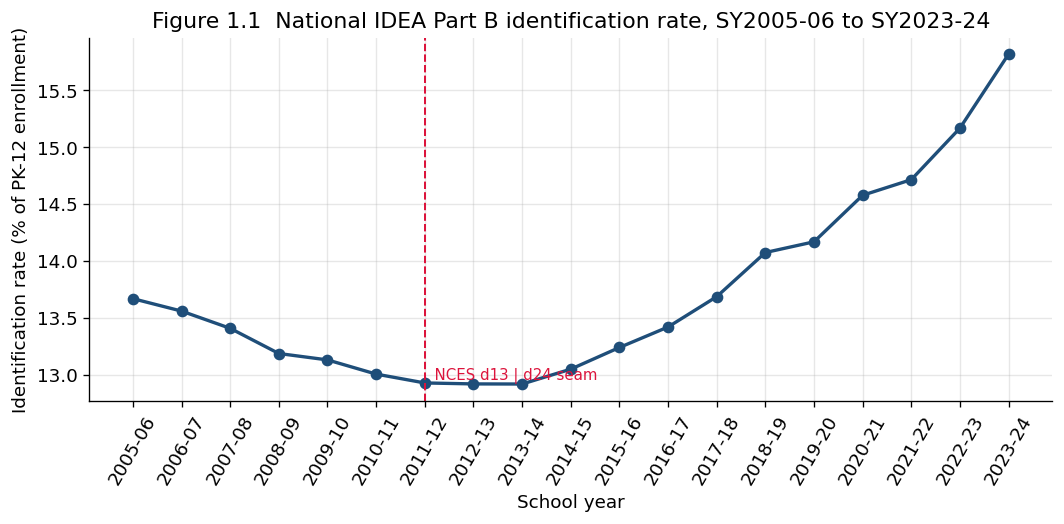

In [3]:
# 분모 비대칭 제거: raw 테이블 직접 SUM 대신 v_identification_rate_national 사용.
# 이 view 는 분자(n_served) NULL 주를 행째 제외하므로, 분자만 빠지고 분모는
# 남는 비대칭이 구조적으로 불가능하다. n_states_included 로 그 해 집계 주 수를 노출.
nat = q('''
  SELECT school_year,
         total_served    AS n_served,
         total_enrolled  AS n_enrolled,
         pct_identified  AS pct,
         n_states_included
  FROM v_identification_rate_national
  ORDER BY school_year''')

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(nat['school_year'], nat['pct'], marker='o', color='#1f4e79', lw=2)
ax.axvline('2011-12', color='crimson', ls='--', lw=1.2)
ax.text('2011-12', nat['pct'].min(), '  NCES d13 | d24 seam', color='crimson', va='bottom', fontsize=9)
ax.set_ylabel('Identification rate (% of PK-12 enrollment)')
ax.set_xlabel('School year')
ax.set_title('Figure 1.1  National IDEA Part B identification rate, SY2005-06 to SY2023-24')
ax.tick_params(axis='x', rotation=60)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig1_1_national_rate.png', bbox_inches='tight')
nat[['school_year','pct','n_states_included']].round(2)

## 3. The numerator/denominator scope mismatch, schematically (Figure 1.2)

Illustrates the two documented upward biases recorded in `meta_metric.asymmetries`: the numerator covers ages 3-21 (and parentally-placed private-school children under an ISP), while the denominator is public-school PK-12 only.

saved


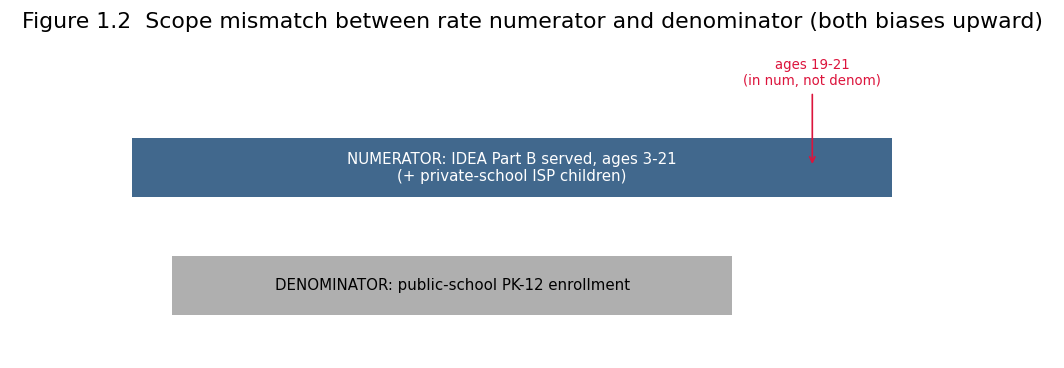

In [4]:
fig, ax = plt.subplots(figsize=(9,3.2))
ax.axis('off')
# Numerator bar
ax.barh(1, 19, left=3, height=0.5, color='#1f4e79', alpha=0.85)
ax.text(3+19/2, 1, 'NUMERATOR: IDEA Part B served, ages 3-21\n(+ private-school ISP children)',
        ha='center', va='center', color='white', fontsize=9)
# Denominator bar
ax.barh(0, 14, left=4, height=0.5, color='#a6a6a6', alpha=0.9)
ax.text(4+14/2, 0, 'DENOMINATOR: public-school PK-12 enrollment',
        ha='center', va='center', color='black', fontsize=9)
# Mismatch annotations
ax.annotate('ages 19-21\n(in num, not denom)', xy=(20,1), xytext=(20,1.7),
            ha='center', fontsize=8, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'))
ax.set_xlim(0,26); ax.set_ylim(-0.6,2.1)
ax.set_title('Figure 1.2  Scope mismatch between rate numerator and denominator (both biases upward)')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig1_2_scope_mismatch.png', bbox_inches='tight')
print('saved')

## 4. Reconciliation: ALL = sum-of-13 holds per band, not at age='ALL' (Figure 1.3)

Verifies the corrected SPEC invariant. For each post-2012 (state, year):
- per band ('3-5','6-21'): raw ALL == sum of 13 categories (exact);
- at age='ALL': raw ALL >= sum of 13 (strict inequality wherever a category has an `ALL_INCOMPLETE_BAND` NULL).

The figure counts, per year, the states where the strict inequality appears at age='ALL'.

Per-band equality violations (post-2012): 0
age=ALL  raw_ALL < sum13 violations (should be 0): 0


school_year
2012-13     0
2013-14    13
2014-15     0
2015-16    13
2016-17    12
2017-18    12
2018-19    10
2019-20     7
2020-21     2
2021-22     2
2022-23     2
2023-24     3
2024-25     3
Name: strict_gt, dtype: int64

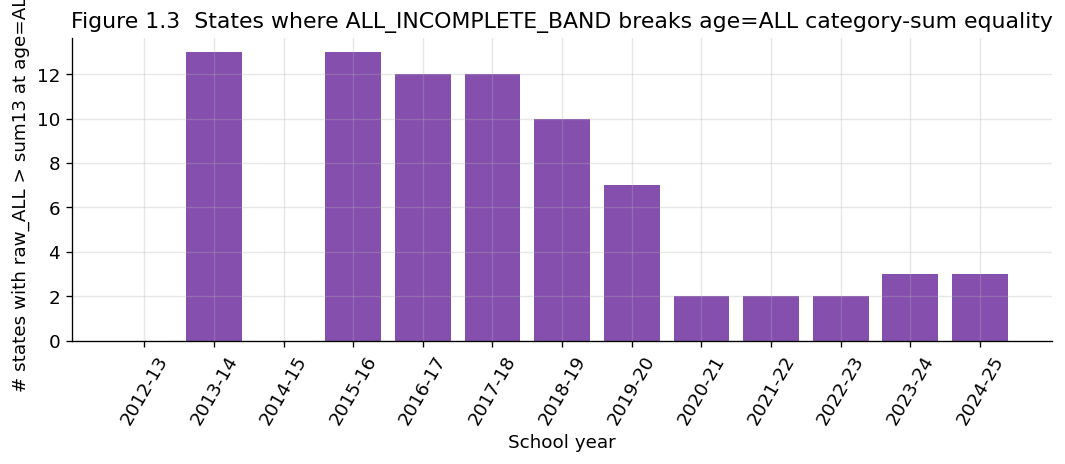

In [5]:
catlist = ','.join(f"'{x}'" for x in FED_CATS)

# Per-band equality check (expect zero violations post-2012, excluding IA noncat & AZ 2024-25 anomaly)
band_df = q(f'''
  WITH s13 AS (
    SELECT school_year, state_code, age_band, SUM(n_students) sum13
    FROM fact_state_disability WHERE disability_code IN ({catlist})
    GROUP BY school_year, state_code, age_band),
  allb AS (
    SELECT school_year, state_code, age_band, n_students AS allv
    FROM fact_state_disability WHERE disability_code='ALL')
  SELECT a.school_year, a.state_code, a.age_band, a.allv, s.sum13
  FROM allb a JOIN s13 s USING(school_year, state_code, age_band)
  WHERE a.school_year >= '2012-13' AND a.age_band IN ('3-5','6-21')
''')
band_df = band_df[~((band_df.state_code=='IA') & (band_df.school_year>='2019-20'))]
band_df = band_df[~((band_df.state_code=='AZ') & (band_df.school_year=='2024-25'))]
band_df = band_df.dropna(subset=['allv','sum13'])
band_viol = int((band_df.allv != band_df.sum13).sum())
print('Per-band equality violations (post-2012):', band_viol)

# age='ALL' inequality count by year
all_df = q(f'''
  WITH s13 AS (
    SELECT school_year, state_code, SUM(n_students) sum13
    FROM fact_state_disability WHERE disability_code IN ({catlist}) AND age_band='ALL'
    GROUP BY school_year, state_code),
  allb AS (
    SELECT school_year, state_code, n_students AS allv
    FROM fact_state_disability WHERE disability_code='ALL' AND age_band='ALL')
  SELECT a.school_year, a.state_code, a.allv, s.sum13
  FROM allb a JOIN s13 s USING(school_year, state_code)
  WHERE a.school_year >= '2012-13'
''')
all_df = all_df[~((all_df.state_code=='IA') & (all_df.school_year>='2019-20'))].dropna(subset=['allv','sum13'])
all_df['strict_gt'] = all_df.allv > all_df.sum13
lt_viol = int((all_df.allv < all_df.sum13).sum())
print('age=ALL  raw_ALL < sum13 violations (should be 0):', lt_viol)
by_year = all_df.groupby('school_year')['strict_gt'].sum().astype(int)

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(by_year.index, by_year.values, color='#7030a0', alpha=0.85)
ax.set_ylabel('# states with raw_ALL > sum13 at age=ALL')
ax.set_xlabel('School year')
ax.set_title('Figure 1.3  States where ALL_INCOMPLETE_BAND breaks age=ALL category-sum equality')
ax.tick_params(axis='x', rotation=60)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig1_3_reconciliation.png', bbox_inches='tight')
by_year

## 5. Data-quality ledger summary (Table 1.3 inputs)

The `meta_dataquality` rows actually present in the build (distinct from the 18 issues *contemplated* in SPEC §5).

In [6]:
dq = q('SELECT issue_code, severity, COUNT(*) n, GROUP_CONCAT(DISTINCT state_code) states FROM meta_dataquality GROUP BY issue_code, severity ORDER BY issue_code')
dq

,issue_code,severity,n,states
0,AGE_BAND_SUPPRESSED,warn,9,"WY,ME,VT,LA,NE,MN"
1,ANOMALY_IMPUTED,block,1,AZ
2,DENOMINATOR_UNPUBLISHED,info,1,None
3,EXOGENOUS_SHOCK,info,1,None
4,NONCATEGORICAL,info,6,IA
5,OSEP_STATE_SUPPRESSED,warn,7,"VT,WI,NM"
6,REPORTING_VS_STATUTORY,info,1,None
7,STATE_POLICY_CAP,info,1,TX


In [7]:
con.close()
print('All figures written to', FIGDIR)

All figures written to figures
